In [ ]:
!pip install -qU transformers datasets evaluate accelerate scikit-learn matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 94.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 104.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.7/47.7 MB 17.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pylibcudf-cu12 25.6.0 requires pyarrow<20.0.0a0,>=14.0.0; platform_machine == "x86_64", but you have pyarrow 22.0.0 which is incompatible.
cudf-cu12 25.6.0 requires pyarrow<20.0.0a0,>=14.0.0; platform_machine == "x86_64", but you have pyarrow 22.0.0 which is incompatible.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset, DatasetDict
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          TrainingArguments, Trainer, Pipeline)
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay
from sklearn.exceptions import UndefinedMetricWarning
import torch
from datasets import load_dataset, DatasetDict
import os
import warnings
import seaborn as sns

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UndefinedMetricWarning)

os.environ["WANDB_DISABLED"] = "true"
os.environ["HF_HUB_DISABLE_TELEMETRY"] = "1"

In [ ]:
# Path to JSONL file
data_path = "/content/fever_train_ready.jsonl"

# Load dataset
dataset = load_dataset("json", data_files={"train": data_path})

print("Sample row:")
print(dataset["train"][0])

# Map textual labels to numeric
label_map = {"SUPPORTS": 0, "REFUTES": 1}

def map_labels(example):
    example["label"] = label_map.get(example["label"], -1)
    return example

# Apply mapping
dataset["train"] = dataset["train"].map(map_labels)

# Filter invalid rows
dataset["train"] = dataset["train"].filter(lambda x: x["label"] != -1)

# Split train → 90% train / 10% validation
split_dataset = dataset["train"].train_test_split(test_size=0.1, seed=42)

# Rebuild as proper DatasetDict
dataset = DatasetDict({
    "train": split_dataset["train"],
    "validation": split_dataset["test"]
})

print(f"Train size: {len(dataset['train'])}, Validation size: {len(dataset['validation'])}")


Sample row:
{'claim': 'Vladimir Putin studied German.', 'evidence_sentences': ['Born in Leningrad -LRB- now Saint Petersburg -RRB- , Putin studied German in high school and speaks the language fluently .\tLeningrad\tSaint Petersburg\tSaint Petersburg\tSaint Petersburg', 'Born in Leningrad -LRB- now Saint Petersburg -RRB- , Putin studied German in high school and speaks the language fluently .\tLeningrad\tSaint Petersburg\tSaint Petersburg\tSaint Petersburg'], 'label': 'SUPPORTS'}


Map:   0%|          | 0/20000 [00:00<?, ? examples/s]

Filter:   0%|          | 0/20000 [00:00<?, ? examples/s]

Train size: 18000, Validation size: 2000


In [ ]:
def combine_text(example):
    example["text"] = f"claim: {example['claim']} evidence: {example['evidence_sentences']}"
    return example

dataset = dataset.map(combine_text)

Map:   0%|          | 0/18000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [ ]:
model_name = "microsoft/deberta-v3-base"
tok = AutoTokenizer.from_pretrained(model_name)

def tokenize(example):
    return tok(example["text"], truncation=True, padding="max_length", max_length=256)

dataset = dataset.map(tokenize, batched=True)
dataset = dataset.rename_column("label", "labels")
dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/convert_slow_tokenizer.py:564: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


Map:   0%|          | 0/18000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

def compute_metrics(pred):
    labels = pred.label_ids
    preds = np.argmax(pred.predictions, axis=1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1": f1_score(labels, preds)
    }

args = TrainingArguments(
    output_dir="./fever_detector",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_steps=50,
    fp16=True,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=dataset["train"],
    eval_dataset=dataset["validation"],
    tokenizer=tok,
    compute_metrics=compute_metrics
)


pytorch_model.bin:   0%|          | 0.00/371M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/371M [00:00<?, ?B/s]

Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-1680228471.py:25: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [ ]:
train_result = trainer.train()

metrics = trainer.evaluate()
print("\n📊 Final Evaluation Metrics:")
for k,v in metrics.items():
    print(f"{k:<10}: {v:.4f}")

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 2, 'bos_token_id': 1}.


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.213000,0.222147,0.948000,0.948361
2,0.127300,0.230390,0.950000,0.950199
3,0.071100,0.258387,0.950000,0.950446



📊 Final Evaluation Metrics:
eval_loss : 0.2584
eval_accuracy: 0.9500
eval_f1   : 0.9504
eval_runtime: 13.8990
eval_samples_per_second: 143.8950
eval_steps_per_second: 4.5330
epoch     : 3.0000


## **Results**

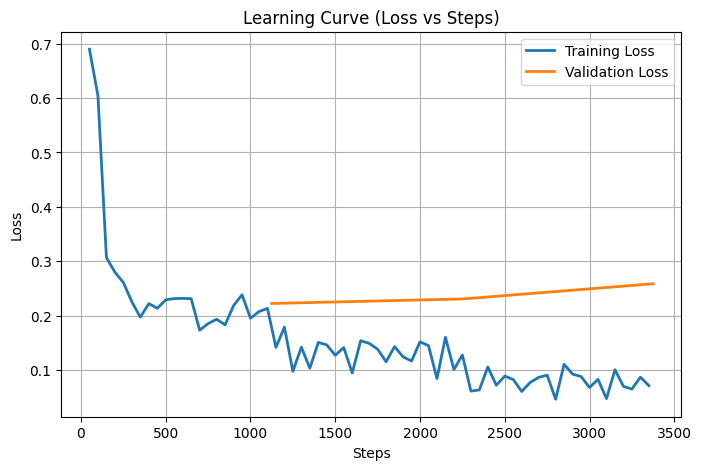

In [ ]:
log_history = pd.DataFrame(trainer.state.log_history)

# Filter training and eval loss
train_loss = log_history[log_history["loss"].notnull()][["step", "loss"]]
eval_loss = log_history[log_history["eval_loss"].notnull()][["step", "eval_loss"]]

plt.figure(figsize=(8,5))
plt.plot(train_loss["step"], train_loss["loss"], label="Training Loss", linewidth=2)
plt.plot(eval_loss["step"], eval_loss["eval_loss"], label="Validation Loss", linewidth=2)
plt.title("Learning Curve (Loss vs Steps)")
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
# Get fine-tuned model predictions
fine_preds = trainer.predict(dataset["validation"])
fine_y_true = fine_preds.label_ids
fine_y_pred = np.argmax(fine_preds.predictions, axis=1)


# Get Baseline model predictions
baseline_model = AutoModelForSequenceClassification.from_pretrained(
    "microsoft/deberta-v3-base", num_labels=2
)

baseline_trainer = Trainer(
    model=baseline_model,
    eval_dataset=dataset["validation"],
    tokenizer=tok,
    compute_metrics=compute_metrics
)

baseline_preds = baseline_trainer.predict(dataset["validation"])
base_y_true = baseline_preds.label_ids
base_y_pred = np.argmax(baseline_preds.predictions, axis=1)

Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).


In [ ]:
print("=== Model After Fine-tuning === \n")
print(classification_report(fine_y_true, fine_y_pred, target_names=["SUPPORTS", "REFUTES"],digits=4))

print("\n=== Baseline: Pretrained Model (Before Fine-tuning) ===\n")
print(classification_report(base_y_true, base_y_pred, target_names=["SUPPORTS", "REFUTES"], digits=4))


=== Model After Fine-tuning === 

              precision    recall  f1-score   support

    SUPPORTS     0.9612    0.9382    0.9495      1003
     REFUTES     0.9393    0.9619    0.9504       997

    accuracy                         0.9500      2000
   macro avg     0.9502    0.9500    0.9500      2000
weighted avg     0.9503    0.9500    0.9500      2000


=== Baseline: Pretrained Model (Before Fine-tuning) ===

              precision    recall  f1-score   support

    SUPPORTS     0.5015    1.0000    0.6680      1003
     REFUTES     0.0000    0.0000    0.0000       997

    accuracy                         0.5015      2000
   macro avg     0.2507    0.5000    0.3340      2000
weighted avg     0.2515    0.5015    0.3350      2000



In [ ]:
from collections import Counter

print("Baseline prediction counts:", Counter(base_y_pred))
print("Fine-tuned prediction counts:", Counter(fine_y_pred))


Baseline prediction counts: Counter({np.int64(0): 2000})
Fine-tuned prediction counts: Counter({np.int64(1): 1021, np.int64(0): 979})


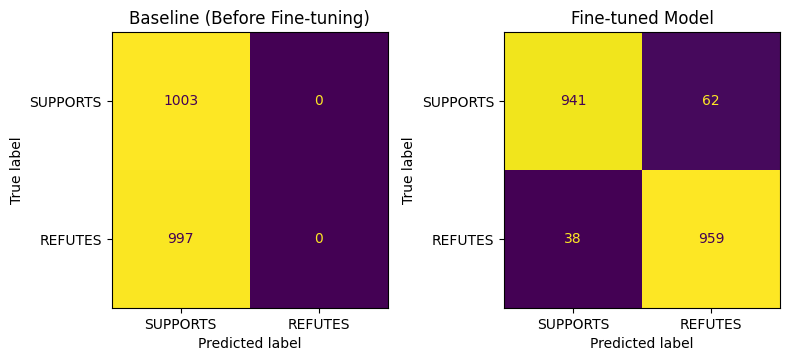

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

# Baseline
cm_base = confusion_matrix(base_y_true, base_y_pred)
ConfusionMatrixDisplay(cm_base, display_labels=["SUPPORTS", "REFUTES"]).plot(ax=axes[0], colorbar=False)
axes[0].set_title("Baseline (Before Fine-tuning)")

# Fine-tuned
cm_fine = confusion_matrix(fine_y_true, fine_y_pred)
ConfusionMatrixDisplay(cm_fine, display_labels=["SUPPORTS", "REFUTES"]).plot(ax=axes[1], colorbar=False)
axes[1].set_title("Fine-tuned Model")

plt.tight_layout()
plt.show()


| Model          | SUPPORTS (0) | REFUTES (1) | What’s happening                                                              |
| -------------- | ------------- | ----------- | ----------------------------------------------------------------------------- |
| **Baseline**   | 2000          | 0           | Predicts **everything as SUPPORTED** → total collapse (no decision boundary)  |
| **Fine-tuned** | 979           | 1021        | Very balanced predictions → model learned to distinguish between both classes |

In other way,

| Stage                  | Behavior                      | Explanation                              |
| ---------------------- | ----------------------------- | ---------------------------------------- |
| **Before fine-tuning** | Predicts only one class       | Model not task-aligned                   |
| **After fine-tuning**  | Learns both classes correctly | Fine-tune adds task-specific supervision |
| **Result**             | All metrics jump              | Indicates proper learning, not a bug     |


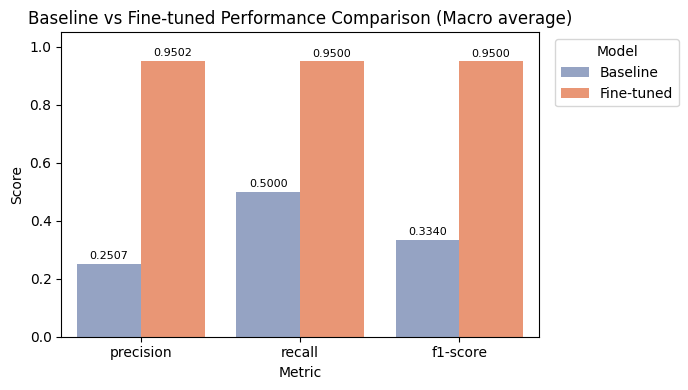

In [ ]:
# --- Reports ---
base_report = classification_report(base_y_true, base_y_pred,
                                    target_names=["SUPPORTED", "REFUTED"],
                                    output_dict=True, zero_division=0,digits=4)
fine_report = classification_report(fine_y_true, fine_y_pred,
                                    target_names=["SUPPORTED", "REFUTED"],
                                    output_dict=True, zero_division=0,digits=4)

# --- Convert to DataFrame and reshape ---
df_base = pd.DataFrame(base_report).T[["precision", "recall", "f1-score"]].reset_index().melt(
    id_vars="index", var_name="Metric", value_name="Score"
)
df_base["Model"] = "Baseline"

df_fine = pd.DataFrame(fine_report).T[["precision", "recall", "f1-score"]].reset_index().melt(
    id_vars="index", var_name="Metric", value_name="Score"
)
df_fine["Model"] = "Fine-tuned"

plot_df = pd.concat([df_base, df_fine])
plot_df = plot_df[plot_df["index"].isin(["SUPPORTED", "REFUTED"])]

# --- Plot ---
plt.figure(figsize=(7,4))
ax = sns.barplot(
    data=plot_df, x="Metric", y="Score", hue="Model",
    palette=["#8da0cb", "#fc8d62"], ci=None
)

# Add values on bars
for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", label_type="edge", fontsize=8, padding=2)

# --- Styling ---
plt.title("Baseline vs Fine-tuned Performance Comparison (Macro average)", fontsize=12)
plt.ylabel("Score")
plt.xlabel("Metric")
plt.ylim(0, 1.05)
plt.legend(title="Model", loc="upper left", bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()


## **Save the model**

In [ ]:
base_model = "microsoft/deberta-v3-base"
save_dir = "./fever_detector_finetuned"

model.save_pretrained(save_dir)
tok.save_pretrained(save_dir)

('./fever_detector_finetuned/tokenizer_config.json',
 './fever_detector_finetuned/special_tokens_map.json',
 './fever_detector_finetuned/spm.model',
 './fever_detector_finetuned/added_tokens.json',
 './fever_detector_finetuned/tokenizer.json')

## **Model in action**

In [ ]:
# Label mapping (adjust if your dataset uses different names)
id2label = {0: "SUPPORTS", 1: "REFUTES"}
label2id = {"SUPPORTS": 0, "REFUTES": 1}

# Load tokenizer and models
tok = AutoTokenizer.from_pretrained("microsoft/deberta-v3-base")

baseline_model = AutoModelForSequenceClassification.from_pretrained(
    "microsoft/deberta-v3-base",
    num_labels=2,
    id2label=id2label,
    label2id=label2id
)
finetuned_model = AutoModelForSequenceClassification.from_pretrained(
    "/content/fever_detector_finetuned",
    num_labels=2,
    id2label=id2label,
    label2id=label2id
)

# Create inference pipelines
baseline_pipe = pipeline("text-classification", model=baseline_model, tokenizer=tok, return_all_scores=True)
finetuned_pipe = pipeline("text-classification", model=finetuned_model, tokenizer=tok, return_all_scores=True)

# Example claims
examples = [
    {
        "claim": "Vitamin C cures cancer.",
        "evidence": "Medical research shows no reliable evidence that Vitamin C cures cancer."
    },
    {
        "claim": "The Eiffel Tower is located in Paris.",
        "evidence": "The Eiffel Tower is a landmark in Paris, France."
    },
    {
        "claim": "COVID-19 vaccines contain microchips.",
        "evidence": "Health authorities confirm COVID-19 vaccines do not contain microchips or tracking devices."
    },
    {
        "claim": "Water boils at 100 degrees Celsius under standard pressure.",
        "evidence": "At one atmosphere pressure, water boils at 100°C."
    }
]

# Compare predictions
for ex in examples:
    text = f"claim: {ex['claim']} evidence: {ex['evidence']}"
    base_res = baseline_pipe(text)[0]
    fine_res = finetuned_pipe(text)[0]

    # Sort and extract
    base_res = sorted(base_res, key=lambda x: x['score'], reverse=True)
    fine_res = sorted(fine_res, key=lambda x: x['score'], reverse=True)

    print("="*80)
    print(f"Claim: {ex['claim']}")
    print(f"Evidence: {ex['evidence']}\n")

    print(f"🔹 Baseline : {base_res[0]['label']} ({base_res[0]['score']:.3f})")
    print(f"🔹 Fine-tuned : {fine_res[0]['label']} ({fine_res[0]['score']:.3f})")

    if base_res[0]['label'] != fine_res[0]['label']:
        print("✅ Fine-tuned model corrected the baseline mistake!\n")


Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Device set to use cuda:0
Device set to use cuda:0


Claim: Vitamin C cures cancer.
Evidence: Medical research shows no reliable evidence that Vitamin C cures cancer.

🔹 Baseline : SUPPORTS (0.544)
🔹 Fine-tuned : REFUTES (0.618)
✅ Fine-tuned model corrected the baseline mistake!

Claim: The Eiffel Tower is located in Paris.
Evidence: The Eiffel Tower is a landmark in Paris, France.

🔹 Baseline : SUPPORTS (0.544)
🔹 Fine-tuned : SUPPORTS (0.999)
Claim: COVID-19 vaccines contain microchips.
Evidence: Health authorities confirm COVID-19 vaccines do not contain microchips or tracking devices.

🔹 Baseline : SUPPORTS (0.541)
🔹 Fine-tuned : REFUTES (0.995)
✅ Fine-tuned model corrected the baseline mistake!

Claim: Water boils at 100 degrees Celsius under standard pressure.
Evidence: At one atmosphere pressure, water boils at 100°C.

🔹 Baseline : SUPPORTS (0.545)
🔹 Fine-tuned : SUPPORTS (0.964)


# **Interpretation**

| Observation                           | Before Fine-tuning (Baseline) | After Fine-tuning (FEVER-trained) |
| ------------------------------------- | ----------------------------- | --------------------------------- |
| **Health misinformation (Vitamin C)** | Hallucinated “supports”       | ✅ Correctly refuted               |
| **Conspiracy (microchips)**           | Hallucinated “supports”       | ✅ Correctly refuted               |
| **Common fact (Eiffel Tower)**        | Correct                       | Correct                           |
| **Scientific law (boiling point)**    | Correct                       | Correct                           |

In [70]:
!jupyter nbconvert --ClearOutputPreprocessor.enabled=True \
    --to notebook --inplace fine_tune_text_model.ipynb

[NbConvertApp] WARNING | pattern 'fine_tune_text_model.ipynb' matched no files
This application is used to convert notebook files (*.ipynb)
        to various other formats.


Options
The options below are convenience aliases to configurable class-options,
as listed in the "Equivalent to" description-line of the aliases.
To see all configurable class-options for some <cmd>, use:
    <cmd> --help-all

--debug
    set log level to logging.DEBUG (maximize logging output)
    Equivalent to: [--Application.log_level=10]
--show-config
    Show the application's configuration (human-readable format)
    Equivalent to: [--Application.show_config=True]
--show-config-json
    Show the application's configuration (json format)
    Equivalent to: [--Application.show_config_json=True]
--generate-config
    generate default config file
    Equivalent to: [--JupyterApp.generate_config=True]
-y
    Answer yes to any questions instead of prompting.
    Equivalent to: [--JupyterApp.answer_yes=True]
--ex